# Trigger studies

In [1]:
import ROOT
import os,sys,json
import argparse
from datetime import date    
import numpy as np
import copy
import math
import mplhep as hep
import matplotlib.pyplot as plt
import csv
from utils import *
ROOT.gROOT.SetBatch(1)
hep.style.use("CMS")

Welcome to JupyROOT 6.24/07


/cvmfs/cms.cern.ch/el8_amd64_gcc10/external/py3-numpy/1.22.4-62e28bace1c65ef46c4a0988f2d65108/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el8_amd64_gcc10/external/py3-numpy/1.22.4-62e28bace1c65ef46c4a0988f2d65108/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/tmp/ipykernel_4051613/2965505125.py:109: RuntimeWarning: invalid value encountered in true_divide
  ax_ratio.plot(Results[name][0], Results[name][1]/Results["L1_All"][1], color=colors[name], linestyle='-')


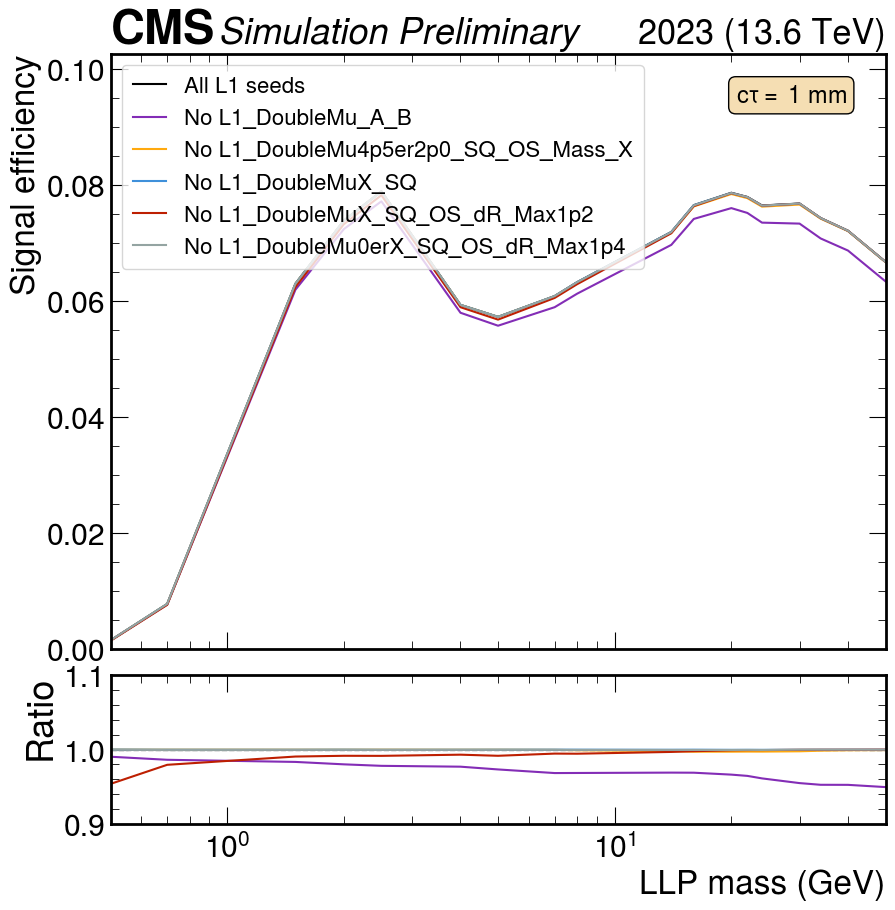

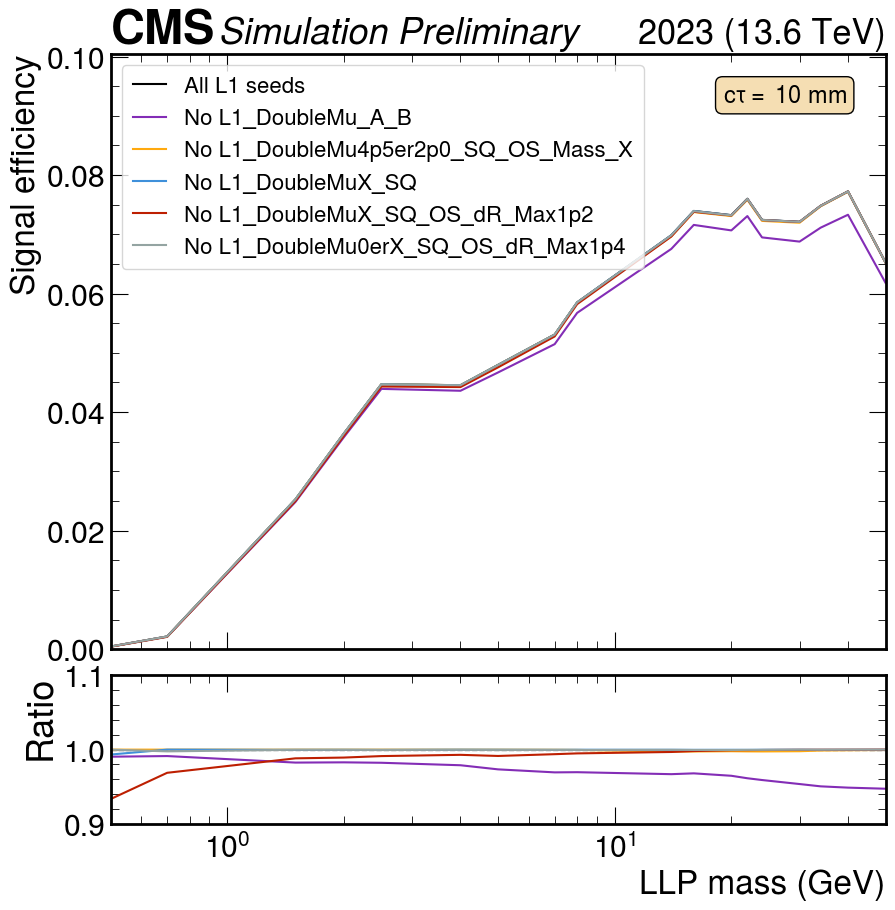

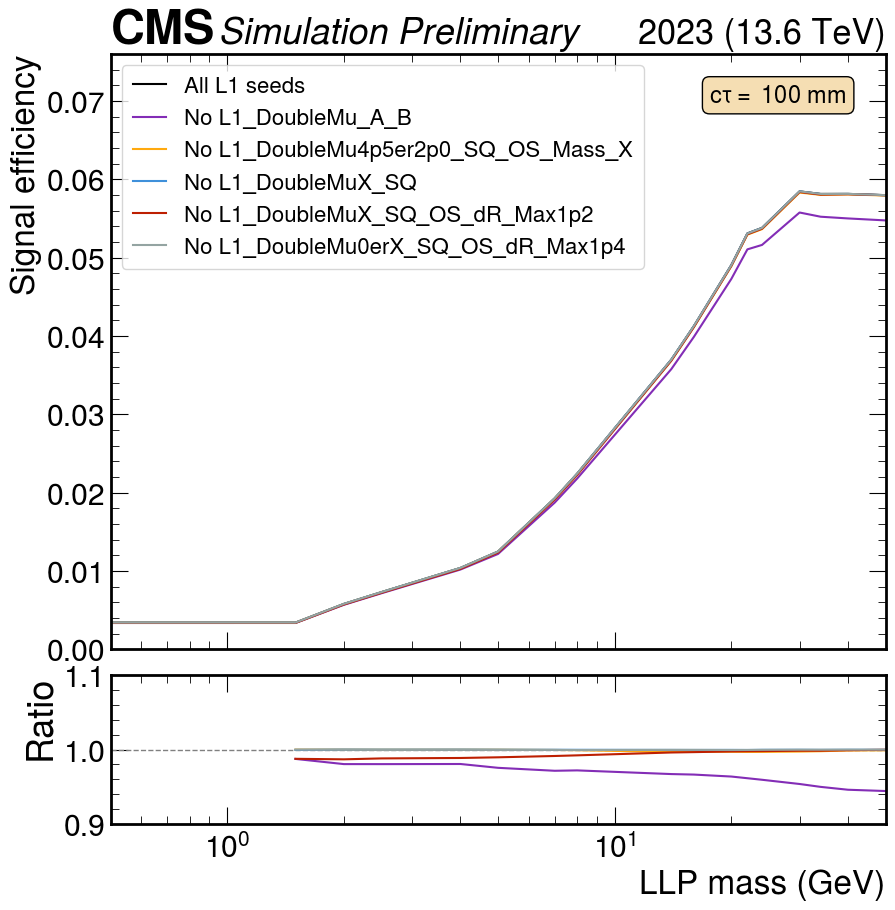

In [2]:
correctByFilter = False
#
sigModel = "HTo2ZdTo2mu2x"
basedir = "/ceph/cms/store/user/fernance/Run3ScoutingOutput/"
#
#
year = 2023
#
#
dNames = []
dNames.append("d_Dimuon_full_inclusive")
#
#
eras = {}
eras[2023] = ['2023', '2022postEE', '2023BPix']
#
#
L1Seeds = [] # name : dir : label
L1Seeds.append(['L1_All', 'outputHistograms_Feb-20-2025_2023_Signal_allSeeds/', 'All L1 seeds'])
L1Seeds.append(['L1_DoubleMu_A_B', 'outputHistograms_Feb-20-2025_2023_Signal_noL1DoubleMu_A_B/', 'No L1_DoubleMu_A_B'])
L1Seeds.append(['L1_DoubleMu4p5er2p0_SQ_OS_Mass_X', 'outputHistograms_Feb-20-2025_2023_Signal_noL1_DoubleMu4p5er2p0_SQ_OS_Mass_X/', 'No L1_DoubleMu4p5er2p0_SQ_OS_Mass_X'])
L1Seeds.append(['L1_DoubleMuX_SQ', 'outputHistograms_Feb-20-2025_2023_Signal_noL1_DoubleMuX_SQ/', 'No L1_DoubleMuX_SQ'])
L1Seeds.append(['L1_DoubleMuX_SQ_OS_dR_Max1p2', 'outputHistograms_Feb-20-2025_2023_Signal_noL1_DoubleMuX_SQ_OS_dR_Max1p2/', 'No L1_DoubleMuX_SQ_OS_dR_Max1p2'])
L1Seeds.append(['L1_DoubleMu0erX_SQ_OS_dR_Max1p4', 'outputHistograms_Feb-20-2025_2023_Signal_noL1_DoubleMu0erX_SQ_OS_dR_Max1p4/', 'No L1_DoubleMu0erX_SQ_OS_dR_Max1p4'])
#
#
if sigModel=="HTo2ZdTo2mu2x":
    sigMasses = [0.5, 0.7, 1.5, 2.0, 2.5, 4.0, 5.0, 7.0, 8.0, 14.0, 16.0, 20.0, 22.0, 24.0, 30.0, 34.0, 40.0, 50.0]
    sigCTaus = [1, 10, 100]
elif sigModel=="BToPhi":
    sigMasses = [0.25, 0.3, 0.4, 0.6, 0.7, 0.9, 1.25, 1.5, 2.0, 3.35, 4.00]
    sigCTaus = [0.1, 1, 10, 100]    
#
#
colors = {}
colors['L1_All']                           = 'k'
colors['L1_DoubleMu_A_B']                  = '#832db6'
colors['L1_DoubleMuX_SQ']                  = '#3f90da'
colors['L1_DoubleMu4p5er2p0_SQ_OS_Mass_X'] = '#ffa90e'
colors['L1_DoubleMuX_SQ_OS_dR_Max1p2']     = '#bd1f01'
colors['L1_DoubleMu0erX_SQ_OS_dR_Max1p4']  = '#94a4a2'
#
#
for d_,d in enumerate(dNames):
    for _t,t in enumerate(sigCTaus):
        #
        #
        Results = {}
        #
        # Loop over seeds
        for L1Seed in L1Seeds:
            #
            name     = L1Seed[0]
            inDir    = L1Seed[1]
            #
            Results[name] = np.zeros((2, len(sigMasses)))
            #
            for m_,m in enumerate(sigMasses):
                #
                if (sigModel=="HTo2ZdTo2mu2x" and ((m < 1.0 and t > 10) or (m < 30.0 and t > 100))):
                    continue
                if sigModel=="HTo2ZdTo2mu2x":
                    sigTag = "Signal_HTo2ZdTo2mu2x_MZd-%s_ctau-%.2fmm"%(str(m).replace('.','p'), t)
                elif sigModel=="BToPhi":
                    sigTag = "Signal_BToPhi_MPhi-%s_ctau-%.2fmm"%(("%.2f"%(m)).replace('.','p'), t)
                #
                for e,era in enumerate(eras[year]):
                    finame = "%s/%s/histograms_%s_%s_%i_0.root"%(basedir,inDir,sigTag,era,year)
                    f = ROOT.TFile(finame)
                    if e==0:
                        dataset = f.Get(d)
                    else:
                        dataset.append(f.Get(d))
                    f.Close()
                nSig = dataset.sumEntries("%f < mfit && mfit < %f"%(m-0.018*5.0*m, m+0.018*5.0*m))
                efilter = 1.0
                if correctByFilter:
                    with open('../data/hahm-request.csv') as mcinfo:
                        reader = csv.reader(mcinfo, delimiter=',')
                        for row in reader:
                            if "MZd-%s"%(str(m).replace('.','p')) in row[0]:
                                efilter = float(row[-1])
                                break
                Results[name][0][m_] = m
                Results[name][1][m_] = nSig/(efilter*2.7*1000)
        #
        plt.style.use(hep.style.CMS)
        fig, (ax, ax_ratio) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.07}, sharex=True, figsize=(10, 10))
        ax.set_ylabel(r'Signal efficiency', fontsize=24)
        ax.set_xlabel('')
        ax.set_xscale('log')
        ax.set_ylim([0.0, 1.3*max(Results['L1_All'][1])])
        ax.set_xlim([sigMasses[0], sigMasses[-1]])
        hep.cms.label("Preliminary", data=False, year=year, com='13.6', ax=ax)
        for l,L1Seed in enumerate(L1Seeds):
            name     = L1Seed[0]
            legLabel = L1Seed[2]
            ax.plot(Results[name][0], Results[name][1], label=legLabel, color=colors[name], linestyle='-')
        ax.legend(loc='upper left', fontsize = 16, frameon = True, ncol=1)
        props = dict(boxstyle='round', facecolor='wheat', alpha=1.0)
        ax.text(0.95, 0.95, r'$c\tau = $ %i mm'%(t), transform=ax.transAxes, fontsize=17, verticalalignment='top',horizontalalignment='right', bbox=props)
        # Ratio
        ax_ratio.axhline(y=1, color='gray', linestyle='--', linewidth=1)
        for l,L1Seed in enumerate(L1Seeds):
            name     = L1Seed[0]
            legLabel = L1Seed[2]
            if 'L1_All' in name:
                continue
            ax_ratio.plot(Results[name][0], Results[name][1]/Results["L1_All"][1], color=colors[name], linestyle='-')
        ax_ratio.set_ylabel("Ratio")
        ax_ratio.set_ylim([0.9, 1.1])
        ax_ratio.set_xlim([sigMasses[0], sigMasses[-1]])
        ax_ratio.set_xlabel(r'LLP mass (GeV)', fontsize=24)
        fig.savefig("L1Efficiency_%s_ctau-%i_paper.png"%(sigModel, t), dpi=140)